In [9]:
import pandas as pd
from matplotlib import pyplot as plt 

df = pd.read_csv('ad_spend.csv')
df.head(3)

,Ad Spend ($),Season,Revenue ($)
0,463,Monsoon,440
1,158,Winter,297
2,328,Monsoon,214


In [2]:
df.shape

(200, 3)

In [3]:
df.isna().sum()

Ad Spend ($)    0
Season          0
Revenue ($)     0
dtype: int64

In [7]:
g = df.groupby('Season')[['Ad Spend ($)', 'Revenue ($)']].mean()
g

,Ad Spend ($),Revenue ($)
Season,,
Monsoon,517.643836,423.150685
Summer,573.836066,689.360656
Winter,552.560606,826.530303


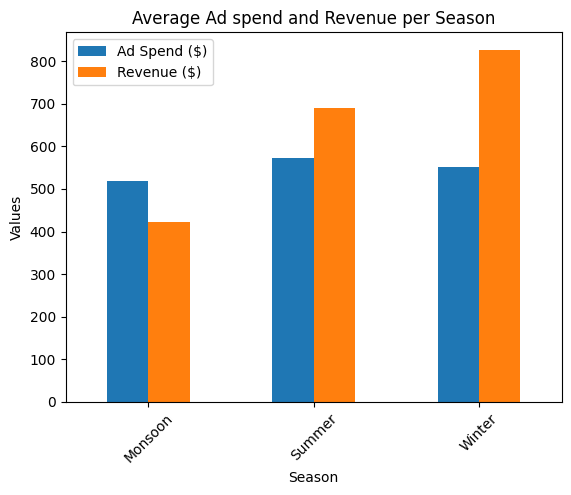

In [10]:
ax = g.plot(kind='bar')
ax.set_title('Average Ad spend and Revenue per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Values')

plt.xticks(rotation = 45)
plt.show()

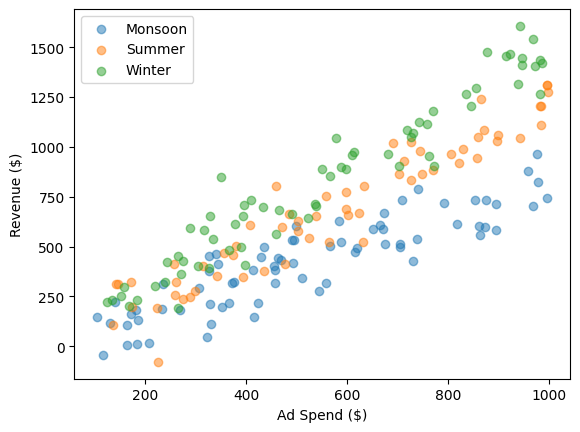

In [13]:
for season, subdf in df.groupby('Season'):
    plt.scatter(subdf['Ad Spend ($)'],subdf['Revenue ($)'],alpha=0.5,label = season)

plt.xlabel('Ad Spend ($)')
plt.ylabel('Revenue ($)')
plt.legend()
plt.show()

In [14]:
df_encoded = pd.get_dummies(df,columns=['Season'],drop_first=True)
df_encoded.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [18]:
from sklearn.model_selection import train_test_split

x = df_encoded[['Ad Spend ($)','Season_Summer','Season_Winter']]
y = df_encoded['Revenue ($)']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=10)

Training Linear Regression Model

In [20]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8882097000477289

Train Decision Tree Regressor

In [21]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8972778553142061

Training GDM

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(x_train,y_train)
model.score(x_test,y_test)


0.9149899654766234